Carregamento do dataset com pandas e visualização de sua estrutura.

In [1]:
import pandas as pd

df = pd.read_csv('StudentPerformanceFactors.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [3]:
df.describe(include='all')

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


Este código calcula quantos valores ausentes existem em cada coluna e identifica quantas categorias únicas há nas variáveis categóricas. Isso nos permite entender a qualidade dos dados, avaliar onde precisamos imputar valores e verificar se existem categorias muito raras que podem atrapalhar a modelagem.

In [4]:
faltantes = df.isnull().sum().sort_values(ascending=False)

cols_cats = df.select_dtypes(include='object').columns
exclusivos = {col: df[col].nunique() for col in cols_cats}

faltantes, exclusivos

(Parental_Education_Level      90
 Teacher_Quality               78
 Distance_from_Home            67
 Hours_Studied                  0
 Attendance                     0
 Gender                         0
 Learning_Disabilities          0
 Physical_Activity              0
 Peer_Influence                 0
 School_Type                    0
 Family_Income                  0
 Tutoring_Sessions              0
 Internet_Access                0
 Motivation_Level               0
 Previous_Scores                0
 Sleep_Hours                    0
 Extracurricular_Activities     0
 Access_to_Resources            0
 Parental_Involvement           0
 Exam_Score                     0
 dtype: int64,
 {'Parental_Involvement': 3,
  'Access_to_Resources': 3,
  'Extracurricular_Activities': 2,
  'Motivation_Level': 3,
  'Internet_Access': 2,
  'Family_Income': 3,
  'Teacher_Quality': 3,
  'School_Type': 2,
  'Peer_Influence': 3,
  'Learning_Disabilities': 2,
  'Parental_Education_Level': 3,
  'Distance_

Foi descoberto que apenas três colunas possuem valores ausentes: `Parental_Education_Level`, `Teacher_Quality` e `Distance_From_Home`. Todas essas variáveis são categóricas. Por as ausências serem em pequena quantidade, a melhor abordagem é preencher os dados faltantes utilizando a categoria mais frequente, a moda,de cada coluna.

Nenhuma variável numérica contêm nulos, o que é ótimo para modelagem.

O trecho abaixo seleciona as colunas com valores ausentes e preenche cada uma com sua categoria mais frequente. Isso garante consistência e evita perda de dados, mantendo a distribuição natural das categorias. Depois da imputação, o código verifica se todas as colunas ficaram sem nulos.

In [5]:
col_nulas = ['Parental_Education_Level', 'Teacher_Quality', 'Distance_from_Home']

for col in col_nulas:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

df.isnull().sum()[col_nulas]

Parental_Education_Level    0
Teacher_Quality             0
Distance_from_Home          0
dtype: int64

Este código seleciona todas as variáveis categóricas e aplica `LabelEncoder`, transformando as categorias em números inteiros. Armazenamos cada encoder em um dicionário caso você precise reverter valores ou aplicar no conjunto de teste mais tarde. Essa etapa prepara os dados para a modelagem.

In [6]:
from sklearn.preprocessing import LabelEncoder

cols_cats = df.select_dtypes(include='object').columns

encoders = {}

for col in cols_cats:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


Este código gera um mapa de calor da matriz de correlação para analisar visualmente como as variáveis se inter-relacionam, especialmente com a nota final, a `Exam_Score`. Isso ajuda a identificar os fatores mais influentes e orienta decisões para os modelos de machine learning.

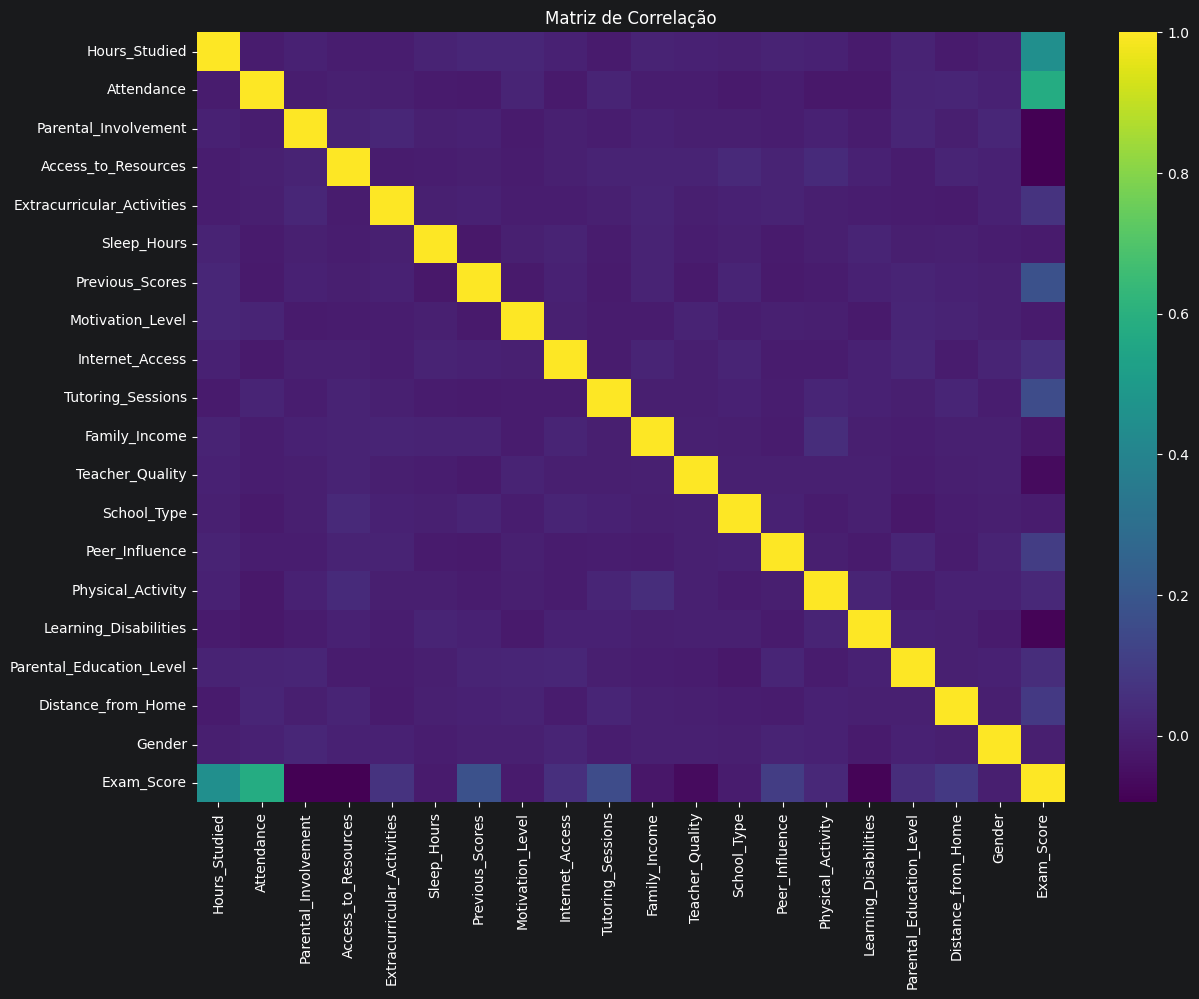

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='viridis')
plt.title('Matriz de Correlação')
plt.show()

O código abaixo trás a mesma informação da matriz de correlação acima, mas em forma de tabela

In [8]:
corr_exam = corr_matrix['Exam_Score'].sort_values(ascending=False)

corr_exam

Exam_Score                    1.000000
Attendance                    0.581072
Hours_Studied                 0.445455
Previous_Scores               0.175079
Tutoring_Sessions             0.156525
Peer_Influence                0.100217
Distance_from_Home            0.088934
Extracurricular_Activities    0.064382
Internet_Access               0.051475
Parental_Education_Level      0.044574
Physical_Activity             0.027824
Gender                       -0.002032
School_Type                  -0.008844
Motivation_Level             -0.014910
Sleep_Hours                  -0.017022
Family_Income                -0.026484
Teacher_Quality              -0.060824
Learning_Disabilities        -0.085066
Access_to_Resources          -0.090503
Parental_Involvement         -0.094289
Name: Exam_Score, dtype: float64

A partir da correlação foi descoberto
- `Attendance` é o fator mais fortemente associado ao desempenho. Estudantes que vão mais à escola tendem a ter notas significativamente maiores.
- `Hours_Studied` tem forte relação direta. O esforço semanal explica grande parte das variações de desempenho.
- Desempenho passado (`Previous_Scores`) influencia, mas bem menos do que presença e estudo.
- Tutoria externa (`Tutoring_Sessions`) ajuda, mas o impacto é moderado.
- Fatores comportamentais/sociais (`Peer_Influence`, `Extracurricular_Activities` e `Internet_Access`) têm pouco impacto.
- `Motivation_Level`, `Sleep_Hours`, `Family_Income` e `School_Type` têm correlação quase zero. Indica que fatores subjetivos ou socioeconômicos, nesta base, não explicam tanto o resultado.
- `Professor_Quality` e `Parental_Involvement` têm baixa relação e negativa. Pode indicar viés no dataset simulado, ou relação mais complexa.

O gráfico abaixo mostra a distribuição das notas, permitindo avaliar se há concentração, outliers ou padrões incomuns. Isso é essencial para entender o comportamento do alvo antes de aplicar modelos de machine learning.

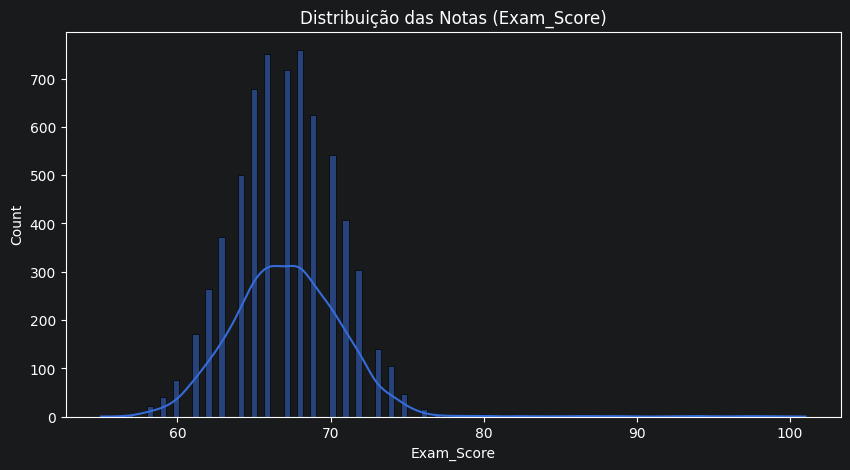

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['Exam_Score'], kde=True)
plt.title('Distribuição das Notas (Exam_Score)')
plt.show()

A distribuição do `Exam_Score` é majoritariamente simétrica e concentrada em torno da mediana, mas apresenta uma leve assimetria à direita (right-skew) devido a alguns valores extremos. Isso significa:
- Concentração Central: A grande maioria dos estudantes teve um desempenho homogêneo, com as notas fortemente concentradas entre 65 e 69.
- Cauda Direita Mais Longa: Existem poucos estudantes com notas excepcionalmente altas (chegando ao pico de 101). Essa minoria de alto desempenho puxa a média (67.23) ligeiramente para cima em relação à mediana (67).
- Ausência de Extremos Negativos: A nota mínima da turma foi 55, indicando que não houve casos de desempenho drasticamente ruim que comprometessem o limite inferior da curva.